In [ ]:
# for the PLS analysis
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter # for smoothing and derivative
from scipy.stats import f as f_dist # for F-distribution T2 limit
from sklearn.cross_decomposition import PLSRegression # the main PLS model, eq to plsregress MATLAB
from sklearn.model_selection import LeaveOneOut, cross_val_predict # for cross-validation
from sklearn.metrics import mean_squared_error, r2_score

# to load the .mat file
import scipy.io as sio
# import urllib.request # to retrieve the data from github, use in local python
import io # to load .mat
import pooch # to retrieve the data, use in google colab

In [14]:
# loading the data, google colab
file_path = pooch.retrieve(
    url="https://raw.githubusercontent.com/FairzanIsLearning/Chemometric-learn/main/Raw_Data/niranastasya.mat",
    known_hash=None
)
raw_data = sio.loadmat(file_path)
print(raw_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'ccalerika', 'ctesterika', 'nircalerika', 'nirtesterika'])


In [16]:
# Loading the data, local python
# raw_data_url = "https://raw.githubusercontent.com/FairzanIsLearning/Chemometric-learn/main/Raw_Data/niranastasya.mat"
# local_filename = "niranastasya.mat"
# raw_data = sio.loadmat("niranastasya.mat")

In [ ]:
# arraging the data
X_cal, y_cal = raw_data["nircalerika"], raw_data["ccalerika"].ravel() 
X_test, y_test = raw_data["nirtesterika"], raw_data["ctesterika"].ravel()
# X/row = samples, Y/column = Wavelength
# .ravel() is used to flatten the shape from 17,1 to 17, since sklearn works better in 1D

wl = np.arange(X_cal.shape[1]) # placeholder of X-acis since the file doesnt address the wavelengths. replace with real axis
xlabel = "Variable index"

print(f"Calibration: {X_cal.shape}, Test: {X_test.shape}")

Calibration: (17, 216), Test: (8, 216)


In [ ]:
# helper functions

# Standard normal variate
def snv(X):
    return (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)
# subtracts each spectrum's own mean and divides by its own standard deviation. It corrects scatter and baseline effects. axis=1 (the 1 in .mean(1)) works along each row, so each spectrum is treated separately.

# Savitzky-golay filter
def sg(X, deriv, win=11, poly=2): # win = window width (xp); poly = poly order
    return savgol_filter(X, win, poly, deriv=deriv, axis=1)
# fits a small polynomial over a sliding window. With deriv=1 it outputs the 1st derivative, which removes constant baseline offsets. deriv=2 removes linear slopes as well but amplifies noise, so I used a wider window (15 points) for it.

# root mean square error
def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

# to test latent variables using leave-one-out cross validation. result in RSMECV
def run_cv(Xp, y, max_lv=10):
    max_lv = min(max_lv, Xp.shape[0] - 2)
    out = []
    for n in range(1, max_lv + 1): 
        pred = cross_val_predict(PLSRegression(n, scale=False), Xp, y, cv=LeaveOneOut()) # scale false because it is mean centering, not scaling the unit variance since every wavelength has the same units
        out.append(rmse(y, pred.ravel()))
    return np.array(out)
# max_lv compresses the wavelengths into a few summary that is called as latent variables/LV. Each LV is a pattern in the spectra that explains concentration. without defining the limit, it will test all the wavelength.
# Choosing the LV count by RMSECV protects against overfitting. Too much LV = overfitting, too low LV = underfitting

# hotelling T2
def t2(T):
    return np.sum(T**2 / T_cal.var(axis=0, ddof=1), axis=1)
# It measures how far a sample is from the centre inside the model space, so it detects extreme samples. Each score is divided by its calibration variance, hence every LV counts equally. The limit comes from the F-distribution at 95% confidence

# Q-residual
def q_res(X, T):
    Xcentered = X - pls._x_mean # the calibration mean that scikit-learn subtracted internally.
    return np.sum((Xcentered - T @ P.T) ** 2, axis=1)
# It measures what the model cannot explain. It reconstructs each spectrum from its scores and sums the squared leftover. 
# A high Q means the spectrum contains something the model has not seen, such as a contaminant or an instrument problem.

In [ ]:
# preprocessing

PREPROCESSING = {
    "Raw":           lambda X: X,
    "SNV":           snv, # remove scatter effects
    "SG 1st deriv":  lambda X: sg(X, 1), # remove baseline offsets and slopes. data X with 1st derivative
    "SG 2nd deriv":  lambda X: sg(X, 2, win=15),
    "SNV + SG 1st":  lambda X: sg(snv(X), 1),
}

In [34]:
# compare the preprocessing result

rows, cv_curves = [], {}
for name, fn in PREPROCESSING.items():
    Xc, Xt = fn(X_cal), fn(X_test)
    cv_curve = run_cv(Xc, y_cal)
    lv = int(np.argmin(cv_curve)) + 1 # to find the best LVs number
    model = PLSRegression(lv, scale=False).fit(Xc, y_cal)
    yc, yp = model.predict(Xc).ravel(), model.predict(Xt).ravel()
    rows.append(dict(Preprocessing=name, LVs=lv,
                     RMSEC=rmse(y_cal, yc), RMSECV=cv_curve.min(), RMSEP=rmse(y_test, yp),
                     R2cal=r2_score(y_cal, yc), R2pred=r2_score(y_test, yp))) #output
    cv_curves[name] = cv_curve
# RMSEC = Error when predicting the calibration samples
# RMSECV = the lowest point of the CV curve, the error at the best LV count
# RMSEP = error when predicting the test set

comparison = pd.DataFrame(rows).set_index("Preprocessing")
print("\n=== Preprocessing comparison (LOO-CV) ===")
print(comparison.round(4).to_string())

best_name = comparison["RMSECV"].idxmin()
print(f"\nSelected preprocessing (lowest RMSECV): {best_name}")


=== Preprocessing comparison (LOO-CV) ===
               LVs   RMSEC  RMSECV   RMSEP   R2cal  R2pred
Preprocessing                                             
Raw              2  0.1024  0.1193  0.0458  0.8576  0.9793
SNV              2  0.1786  0.2206  0.1511  0.5666  0.7738
SG 1st deriv     2  0.1056  0.1248  0.0426  0.8485  0.9820
SG 2nd deriv     4  0.0299  0.1455  0.0789  0.9878  0.9383
SNV + SG 1st     1  0.2334  0.2590  0.2480  0.2601  0.3906

Selected preprocessing (lowest RMSECV): Raw


In [33]:
# How to interpret them:

# If RMSEC <<< RMSECV = model is overfitting. 
# ex: the 2nd derivative has RMSEC 0.030 but RMSECV 0.146, which is a clear example.

# If RMSECV is close to RMSEP = model is stable. 
# This sample RMSEP is lower than RMSECV, which is likely because only 8 test samples makes the number noisy.
# You judge the size of the error against the range of your concentrations (0.12 to 1.2). That is what RPD does.

In [ ]:
# PLS model

fn = PREPROCESSING[best_name]
Xc, Xt = fn(X_cal), fn(X_test)
n_lv = int(comparison.loc[best_name, "LVs"])
pls = PLSRegression(n_lv, scale=False).fit(Xc, y_cal)

yc  = pls.predict(Xc).ravel() # prediction for calibration samples
ycv = cross_val_predict(PLSRegression(n_lv, scale=False), Xc, y_cal, cv=LeaveOneOut()).ravel() # cross-validated prediction
yp  = pls.predict(Xt).ravel() # prediction for the test set

summary = pd.DataFrame({
    "Set":  ["Calibration", "Cross-validation", "Test"],
    "RMSE": [rmse(y_cal, yc), rmse(y_cal, ycv), rmse(y_test, yp)],
    "R2":   [r2_score(y_cal, yc), r2_score(y_cal, ycv), r2_score(y_test, yp)],
    "Bias": [np.mean(yc - y_cal), np.mean(ycv - y_cal), np.mean(yp - y_test)], # mean of (predicted − reference). A value near 0 means no systematic over- or under-prediction
    "RPD":  [y_cal.std(ddof=1) / rmse(y_cal, yc),
             y_cal.std(ddof=1) / rmse(y_cal, ycv),
             y_test.std(ddof=1) / rmse(y_test, yp)],
}).set_index("Set")
# RPD is the standard deviation of the reference values divided by the RMSE. Higher is better. The rule of thumb is that above 2 is usable for screening and above 3 is good for quantification. 
# ddof=1 means the sample standard deviation.

print(f"\n=== Final model: {best_name}, {n_lv} LVs ===")
print(summary.round(4).to_string())


=== Final model: Raw, 2 LVs ===
                    RMSE      R2    Bias     RPD
Set                                             
Calibration       0.1024  0.8576 -0.0000  2.7313
Cross-validation  0.1193  0.8067  0.0025  2.3447
Test              0.0458  0.9793  0.0254  7.4225


In [ ]:
# detecting outlier(s)

T_cal = pls.transform(Xc) # score. each sample's coordinates in the latent-variable space.
T_tst = pls.transform(Xt)
P = pls.x_loadings_ # the spectral patterns of the LVs
n = Xc.shape[0]

# the test calibration set
T2_cal, T2_tst = t2(T_cal), t2(T_tst)
Q_cal, Q_tst = q_res(Xc, T_cal), q_res(Xt, T_tst)

# the model limit
T2_lim = n_lv * (n - 1) * (n + 1) / (n * (n - n_lv)) * f_dist.ppf(0.95, n_lv, n - n_lv)
Q_lim = np.percentile(Q_cal, 95)

# spot the outliers
flag_cal = np.where((T2_cal > T2_lim) | (Q_cal > Q_lim))[0] # check calibration samples
flag_tst = np.where((T2_tst > T2_lim) | (Q_tst > Q_lim))[0] # check test samples
print(f"\nPossible outliers (95% limits) -> calibration samples: {flag_cal.tolist()}, "
      f"test samples: {flag_tst.tolist()}  (0-based index)")
# boths ample groupa re judged from lim defined by the calibration set


Possible outliers (95% limits) -> calibration samples: [16], test samples: [1, 2, 3, 4, 5, 6]  (0-based index)


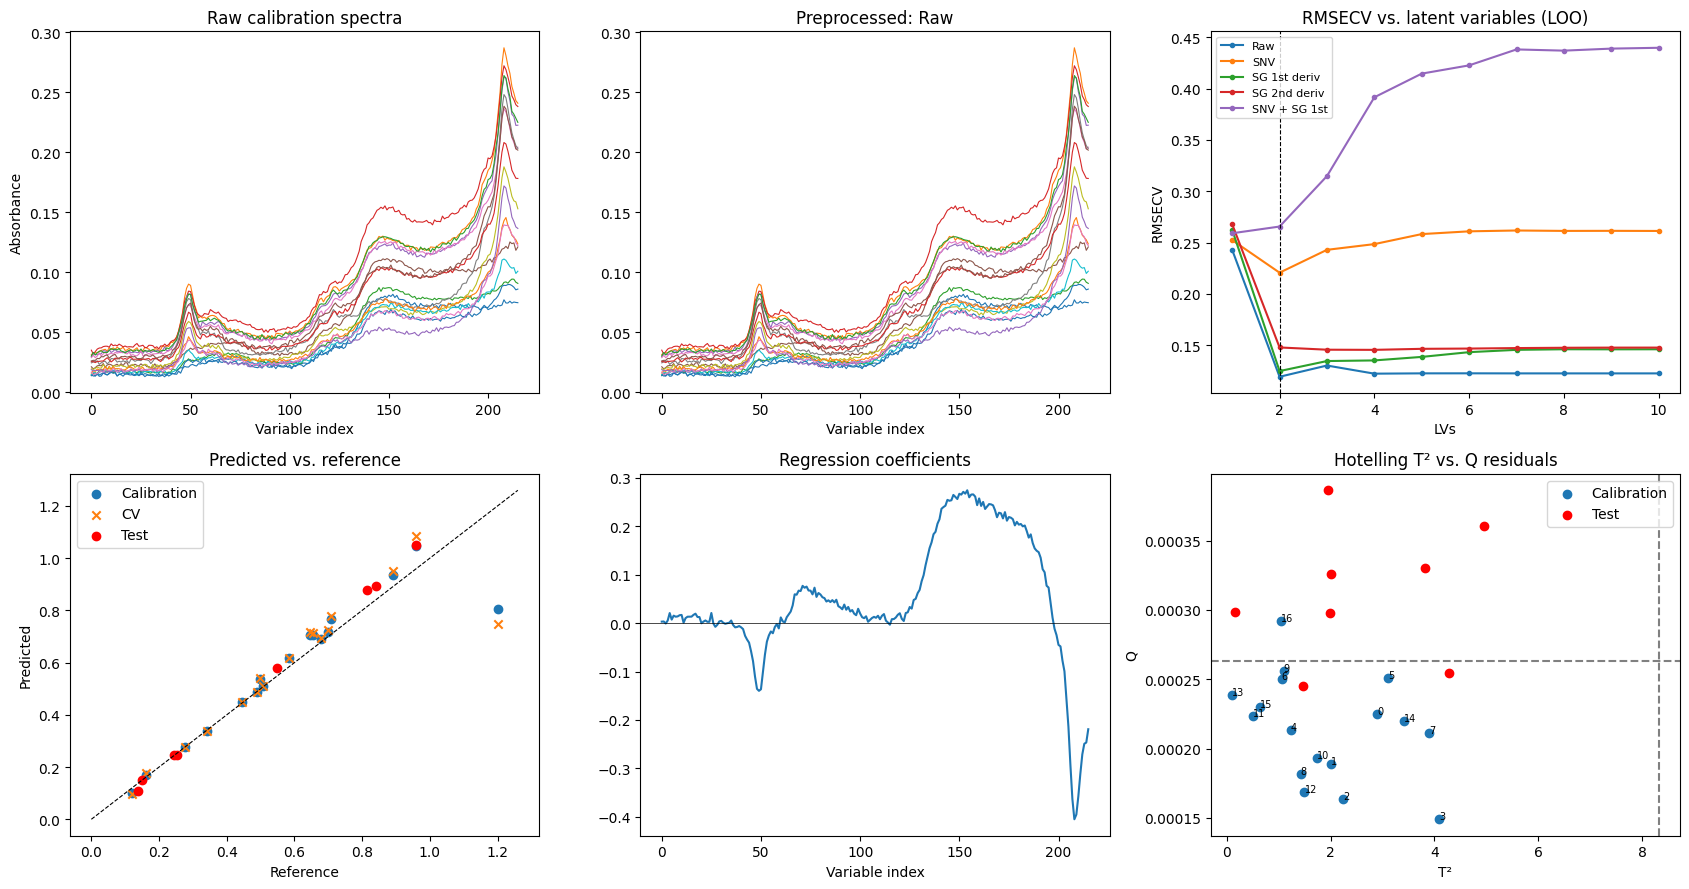

In [ ]:
# PLS plot

fig, ax = plt.subplots(2, 3, figsize=(17, 9))

# raw spectra
ax[0, 0].plot(wl, X_cal.T, lw=0.8)
ax[0, 0].set(title="Raw calibration spectra", xlabel=xlabel, ylabel="Absorbance")

# preprocessed spectra
ax[0, 1].plot(wl, Xc.T, lw=0.8)
ax[0, 1].set(title=f"Preprocessed: {best_name}", xlabel=xlabel)

# RMSECV curves for every method
for name, curve in cv_curves.items():
    ax[0, 2].plot(range(1, len(curve) + 1), curve, "o-", ms=3, label=name)
ax[0, 2].axvline(n_lv, ls="--", c="k", lw=0.8) # the selected LV count
ax[0, 2].set(title="RMSECV vs. latent variables (LOO)", xlabel="LVs", ylabel="RMSECV")
ax[0, 2].legend(fontsize=8)
# aim for the model with the minimum RMSECV 

# predicted vs. reference points
lim = [0, max(y_cal.max(), y_test.max()) * 1.05]
ax[1, 0].scatter(y_cal, yc, label="Calibration")
ax[1, 0].scatter(y_cal, ycv, marker="x", label="CV")
ax[1, 0].scatter(y_test, yp, c="r", label="Test")
ax[1, 0].plot(lim, lim, "k--", lw=0.8)
ax[1, 0].set(title="Predicted vs. reference", xlabel="Reference", ylabel="Predicted")
ax[1, 0].legend()

# regression coefficients
ax[1, 1].plot(wl, pls.coef_.ravel())
ax[1, 1].axhline(0, c="k", lw=0.5)
ax[1, 1].set(title="Regression coefficients", xlabel=xlabel)
# Peaks show which wavelengths drive the prediction

# T2 vs. Q
ax[1, 2].scatter(T2_cal, Q_cal, label="Calibration")
ax[1, 2].scatter(T2_tst, Q_tst, c="r", label="Test")
ax[1, 2].axvline(T2_lim, ls="--", c="gray"); ax[1, 2].axhline(Q_lim, ls="--", c="gray")
for i, (a, b) in enumerate(zip(T2_cal, Q_cal)):
    ax[1, 2].annotate(str(i), (a, b), fontsize=7)
ax[1, 2].set(title="Hotelling T² vs. Q residuals", xlabel="T²", ylabel="Q")
ax[1, 2].legend()

plt.tight_layout()
plt.savefig("pls_full_results.png", dpi=150)
plt.show()

In [ ]:
# export to CSV if needed

# comparison.to_csv("pls_preprocessing_comparison.csv")
# pd.concat([
#    pd.DataFrame({"Set": "Calibration", "Reference": y_cal, "Predicted": yc, "CV_predicted": ycv}),
#    pd.DataFrame({"Set": "Test", "Reference": y_test, "Predicted": yp}),
#]).to_csv("pls_predictions.csv", index=False)
#print("\nSaved: pls_full_results.png, pls_preprocessing_comparison.csv, pls_predictions.csv")